## Notebook 2: Neural Ordinary Differential Equations (NODEs) Collocation Training

This notebook illustrates the training and prediction of a very simple Neural Ordinary Differential Equations (NODEs) model.  The data is fictitiously generated from solving

$\frac{du}{dt}=-u^2$

with initial condition $u(0)=1.0$. Training data is generated for $t\in[0,2]$. The intention is to try to use the NODEs model to predict the solution for $t\in[0,5]$.  

The NODEs model look like

$\frac{du}{dt}=NN(u;\vec{p})$


The Neural Network has one input, $u$ and one output $du(t)/dt$.  In this Notebook, the parameters of the Neural Network, $NN(u;\vec{p})$, will be trained using the derivative of the training data $u_i$.   The method presented in this notebook is commonly referred to as the *collocation* method.



The derivative of $u_i$ is given by the `collocate_data()` function in the SciML ecosystem in Julia

  
---

In [91]:
using ComponentArrays
using Lux
using DiffEqFlux 
using OrdinaryDiffEq
using SciMLSensitivity
using Optimization
using OptimizationOptimisers
using Random
using CairoMakie
using MLUtils
using OrdinaryDiffEqTsit5

Training parameters

In [92]:
max_iter_colloc=10_000
learning_rate=0.1

0.1

Parameters of the training and validation data set

In [93]:
u0 = Float32[1.0]
datasize = 150
tspan = (0.0f0, 2.0f0)
tsteps = range(tspan[1], tspan[2]; length = datasize)


tspan2 = (0.0f0, 5.0f0)
tsteps2 = range(tspan2[1], tspan2[2]; length = 200)

#EpanechnikovKernelBandwidth=0.2
EpanechnikovKernelBandwidth=0.5
noise=0.002

0.002

Define governing equation

$\frac{du}{dt}=-u^2$


In [94]:
function trueODEfunc(du, u, p, t)
    du[1]=-u[1]*u[1]
end

trueODEfunc (generic function with 1 method)

Generating training data

In [95]:
prob_trueode = ODEProblem(trueODEfunc, u0, tspan)
data = Array(solve(prob_trueode, Tsit5(); saveat = tsteps)) .+ noise*randn(length(u0), datasize)

1×150 Matrix{Float64}:
 1.00028  0.984599  0.97153  0.961948  …  0.339685  0.333963  0.330884

Generating Validation data

In [96]:
prob_trueode_sol = ODEProblem(trueODEfunc, u0, tspan2)
data_true = Array(solve(prob_trueode_sol, Tsit5(); saveat = tsteps2)) 

1×200 Matrix{Float32}:
 1.0  0.97549  0.952153  0.929907  0.908676  …  0.168083  0.167376  0.166675

Using the `collocate_data()` function in Julia to smooth the data and approximate the derivative of the smoothed dataset. 

In [97]:
du, u = collocate_data(data, tsteps, EpanechnikovKernel(),EpanechnikovKernelBandwidth)

([-0.8308690053864738 -0.8184323850275751 … -0.10078072493744325 -0.09939597502169993], [0.9485636467965188 0.9404368670765583 … 0.3288547119664662 0.3270306689611724])

Plotting the output of the `collocate_data()` function to see if they look reasonable

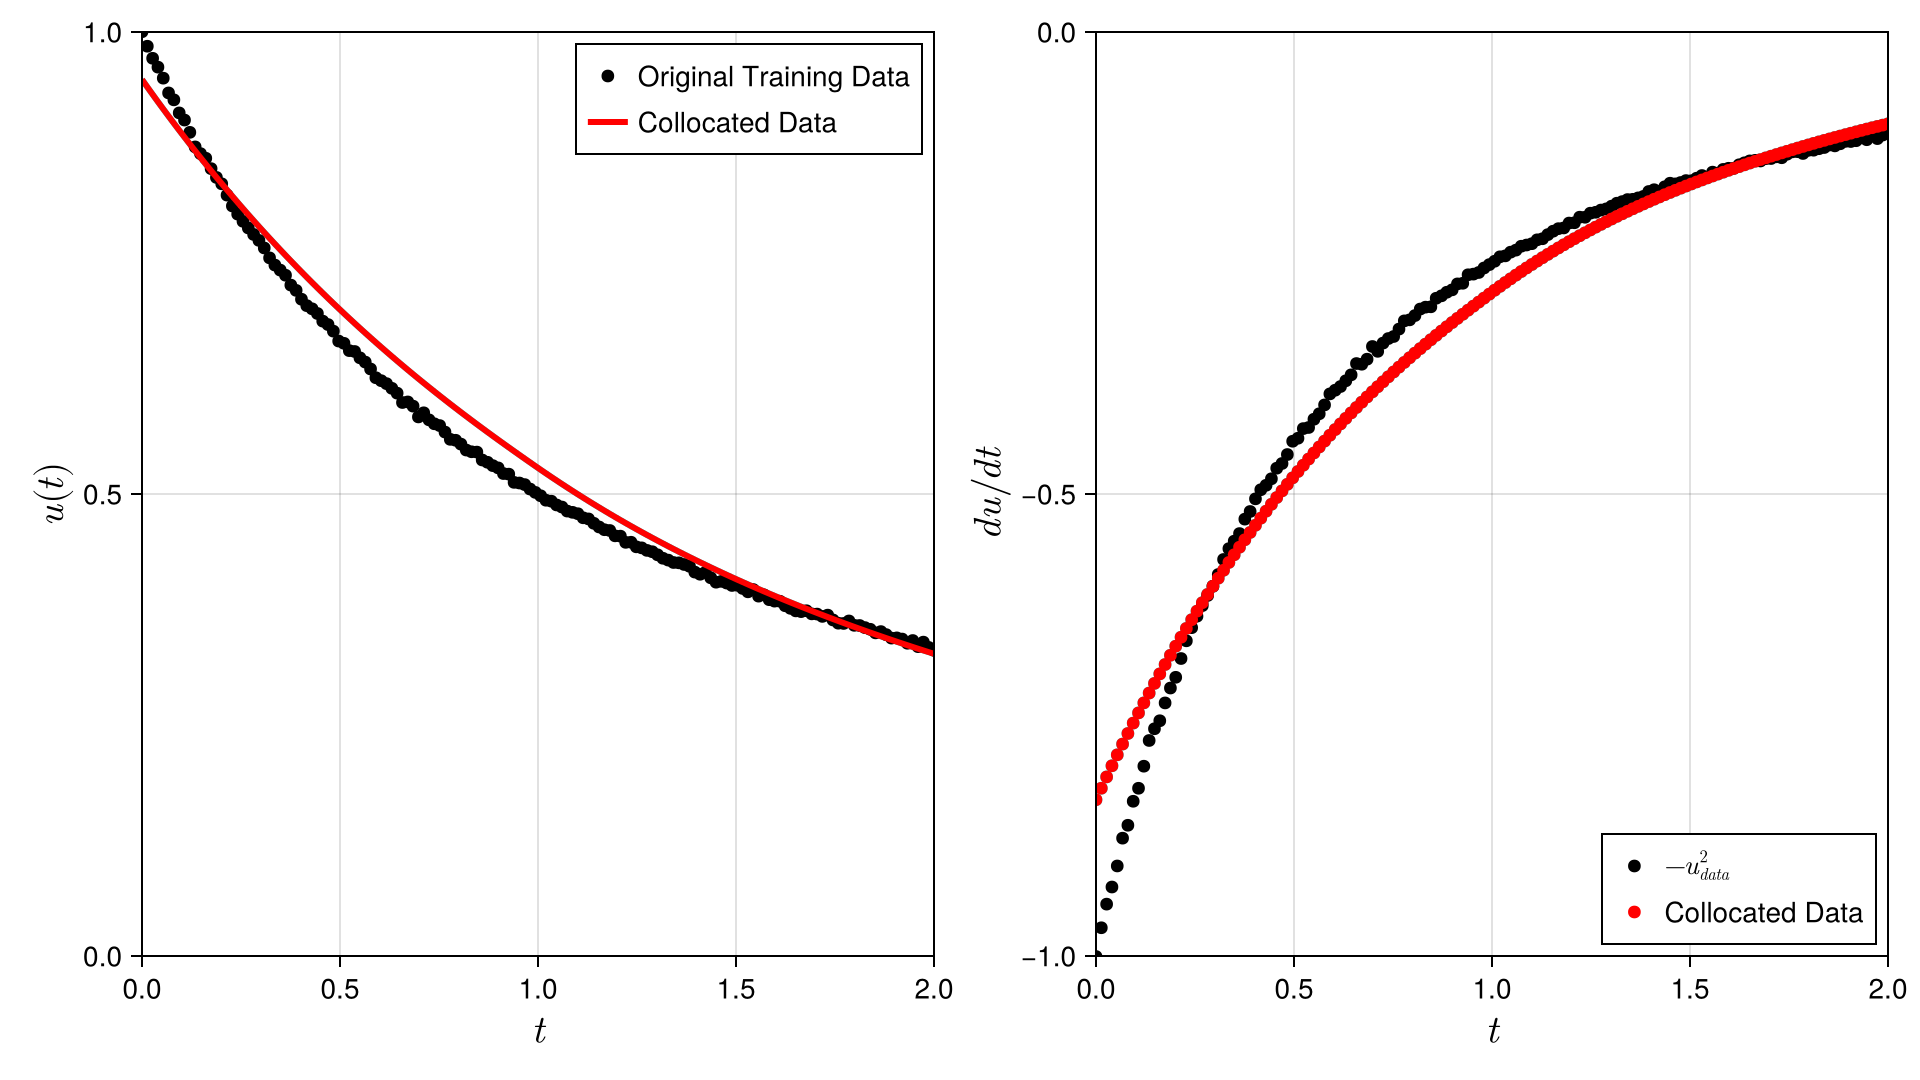

In [98]:
fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax1 = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)")
CairoMakie.scatter!(ax1,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax1,tsteps, u[1,:]; linewidth=3,color=:red,label="Collocated Data")
xlims!(ax1,0,2)
ylims!(ax1,0,1)
axislegend(ax1;position=:rt)

ax2 = CairoMakie.Axis(fig[1, 2],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"du/dt")
CairoMakie.scatter!(ax2,tsteps, -data[1,:].*data[1,:];color=:black,label=L"-u_{data}^2")
CairoMakie.scatter!(ax2,tsteps, du[1,:];color=:red,label="Collocated Data")
xlims!(ax2,0,2)
ylims!(ax2,-1,0)
axislegend(ax2;position=:rb)

#save("figures/02_OriginalDataWithApproximation.png", fig)
#save("figures/02_OriginalData.png", fig)
#save("figures/02_ApproximationOnly.png", fig)
fig

Define Neural Network model,$NN(u;\vec{p})$ (for $\frac{du}{dt}=NN(u;\vec{p})$).  One input layer and one output layer with one node.  Two hidden layers with 3 nodes and using the tanh activation function for the input and hidden layers.

In [99]:
rng = Xoshiro(0)

dudtNODEs = Chain(Dense(1, 3, tanh),
            Dense(3, 3, tanh),
             Dense(3, 1))
pinit, st = Lux.setup(rng, dudtNODEs)

((layer_1 = (weight = Float32[-0.08216114; -0.54444456; -2.7860525;;], bias = Float32[-0.5999714, 0.72428167, -0.4585489]), layer_2 = (weight = Float32[-0.6418321 -1.2789088 -0.2807452; 0.5387089 1.2171224 0.67334807; -0.54372525 -1.3020481 0.47613382], bias = Float32[-0.14210694, -0.5443836, -0.20890224]), layer_3 = (weight = Float32[0.9969245 0.7939795 0.45440757], bias = Float32[-0.3961207])), (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()))

Plot the initial prediction of the Neural Network with the data 

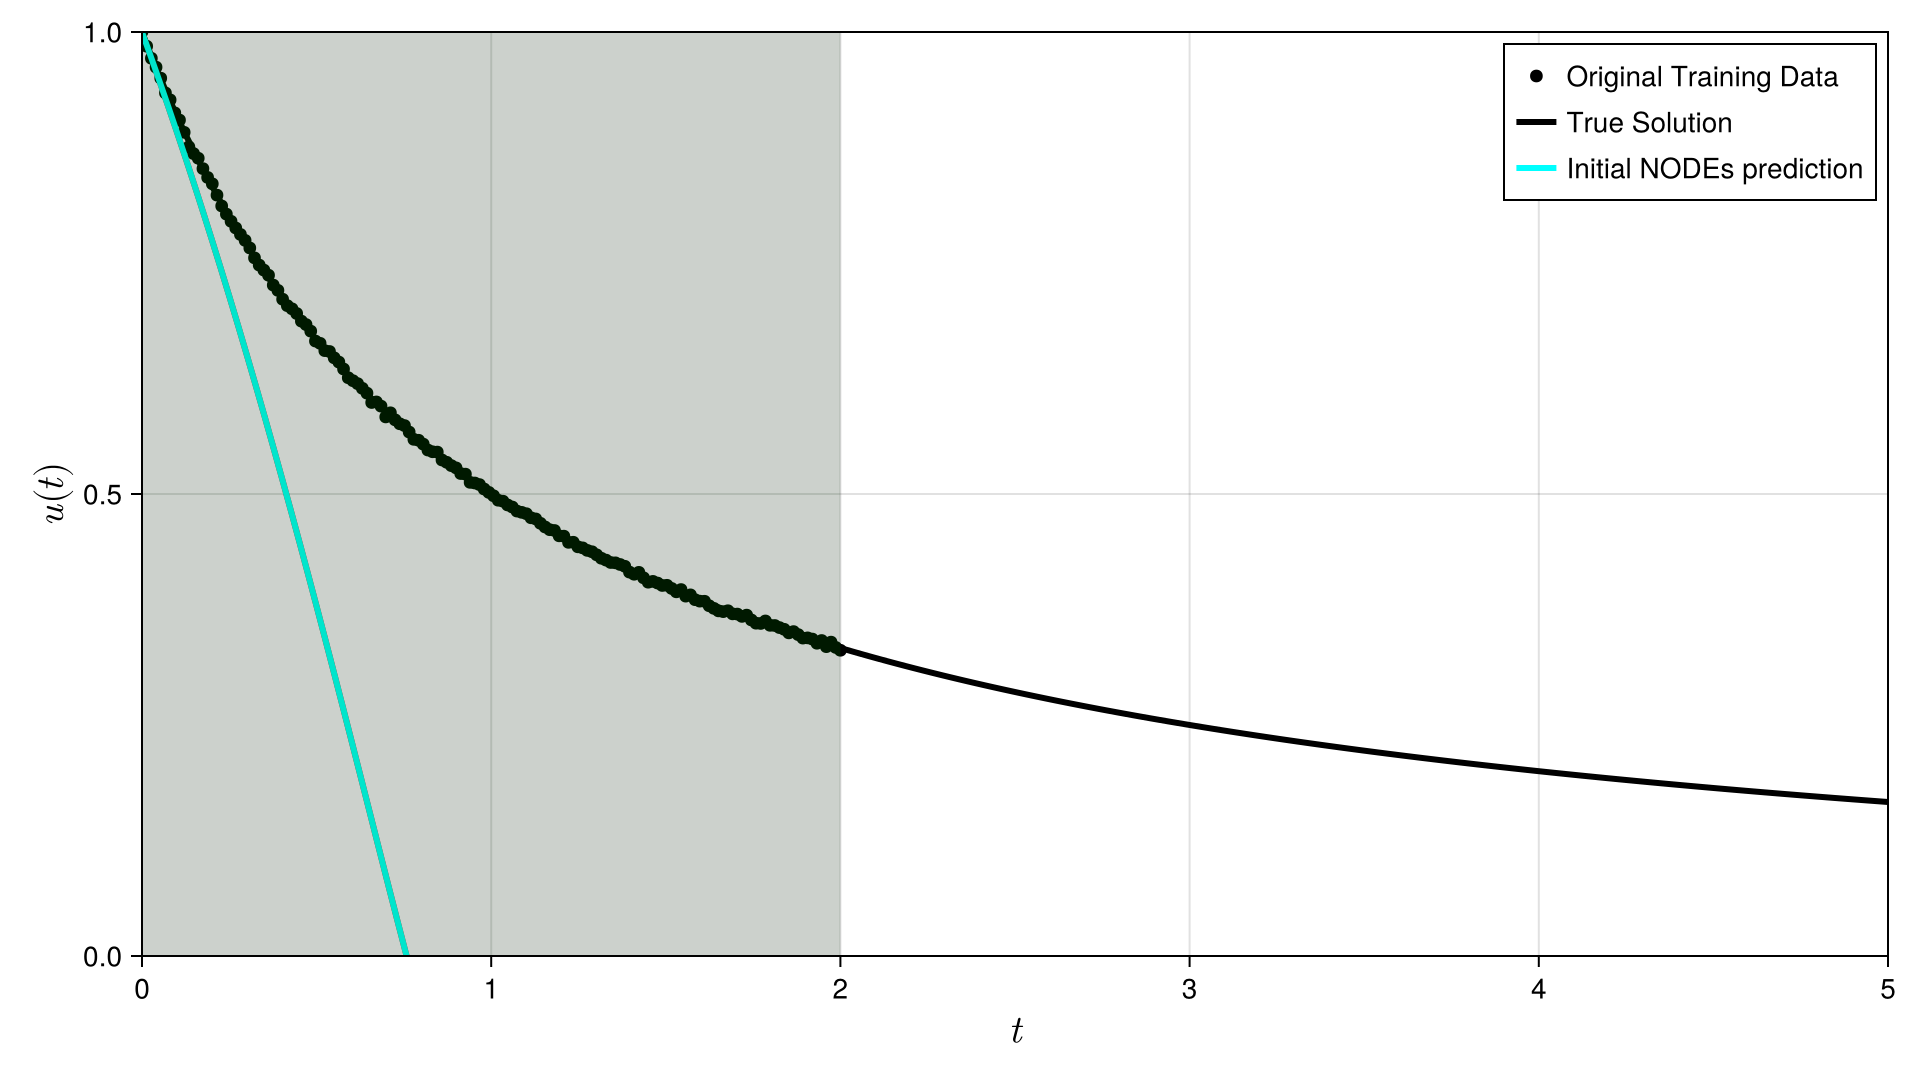

In [100]:
smodel_colloc = StatefulLuxLayer(dudtNODEs, pinit, st)
dudt_colloc(u, p, t) = smodel_colloc(u, p)
prob_colloc = ODEProblem(dudt_colloc, u0, (tspan2[1], tspan2[2]),pinit)
nn_sol_colloc = solve(prob_colloc, Tsit5(); sensealg=InterpolatingAdjoint(), saveat=tsteps2)
ComputedSolutionColloc=convert(AbstractArray,nn_sol_colloc)

fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)")
CairoMakie.scatter!(ax,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax,nn_sol_colloc.t,ComputedSolutionColloc[1,:]; linewidth = 3,color=:cyan,linestyle=:solid,label="Initial NODEs prediction")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:green, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
axislegend(ax;position=:rt)
#save("figures/02_NeuralODEsCollocationTraining.png", fig)
fig

Define the loss function.

$\mathcal{L}(\vec{p})=\frac{1}{2}\frac{1}{N}\sum\limits_{i=1}^{N}(NN(u_i;\vec{p})-du/dt(t_i))^2$

In [101]:
function loss(p,(du, u))
    cost = zero(first(p))
    for i in 1:size(du, 2)
        _du, _ = dudtNODEs(@view(u[:, i]), p, st)
        dui = @view du[:, i]
        cost += sum(abs2, _du  .- dui)
    end
    return 0.5*cost/size(du, 2)
end

loss (generic function with 1 method)

Collocation training

In [102]:
# Initialize a vector to store loss values
loss_history = Float64[]

callback = function (p, l)
    if p.iter % 1000 == 0
        println("Iteration: $(p.iter), Loss: $l")
    end
    push!(loss_history, l)
    return false
end

adtype = Optimization.AutoZygote()
optf = Optimization.OptimizationFunction((p, x) -> loss(p,(du,u)), adtype)
optprob = Optimization.OptimizationProblem(optf, ComponentArray(pinit),(du,u))
result_neuralode = Optimization.solve(optprob, OptimizationOptimisers.Adam(learning_rate); callback, epochs =max_iter_colloc)


Iteration: 1000, Loss: 1.748123437879461e-6
Iteration: 2000, Loss: 2.6466096938607516e-6
Iteration: 3000, Loss: 1.355612966938434e-6
Iteration: 4000, Loss: 2.587082447995402e-7
Iteration: 5000, Loss: 2.284653563120798e-5
Iteration: 6000, Loss: 1.7106177073247695e-6
Iteration: 7000, Loss: 7.22614999265312e-6
Iteration: 8000, Loss: 3.317147869508683e-6
Iteration: 9000, Loss: 1.5533566903815744e-6
Iteration: 10000, Loss: 7.062973940587331e-7
Iteration: 10000, Loss: 2.265297063553623e-7


retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.35775906; -1.370447; -2.1426837;;], bias = Float32[-0.5098123, 0.8422587, 2.4023614]), layer_2 = (weight = Float32[-0.90323615 -0.6747236 -0.88725173; -0.2536362 1.7407156 0.57242954; -0.55917865 -2.0820658 0.34763613], bias = Float32[0.21588433, 0.2928529, -0.13953125]), layer_3 = (weight = Float32[-0.09080348 0.38718843 -0.21919963], bias = Float32[-0.5503384]))

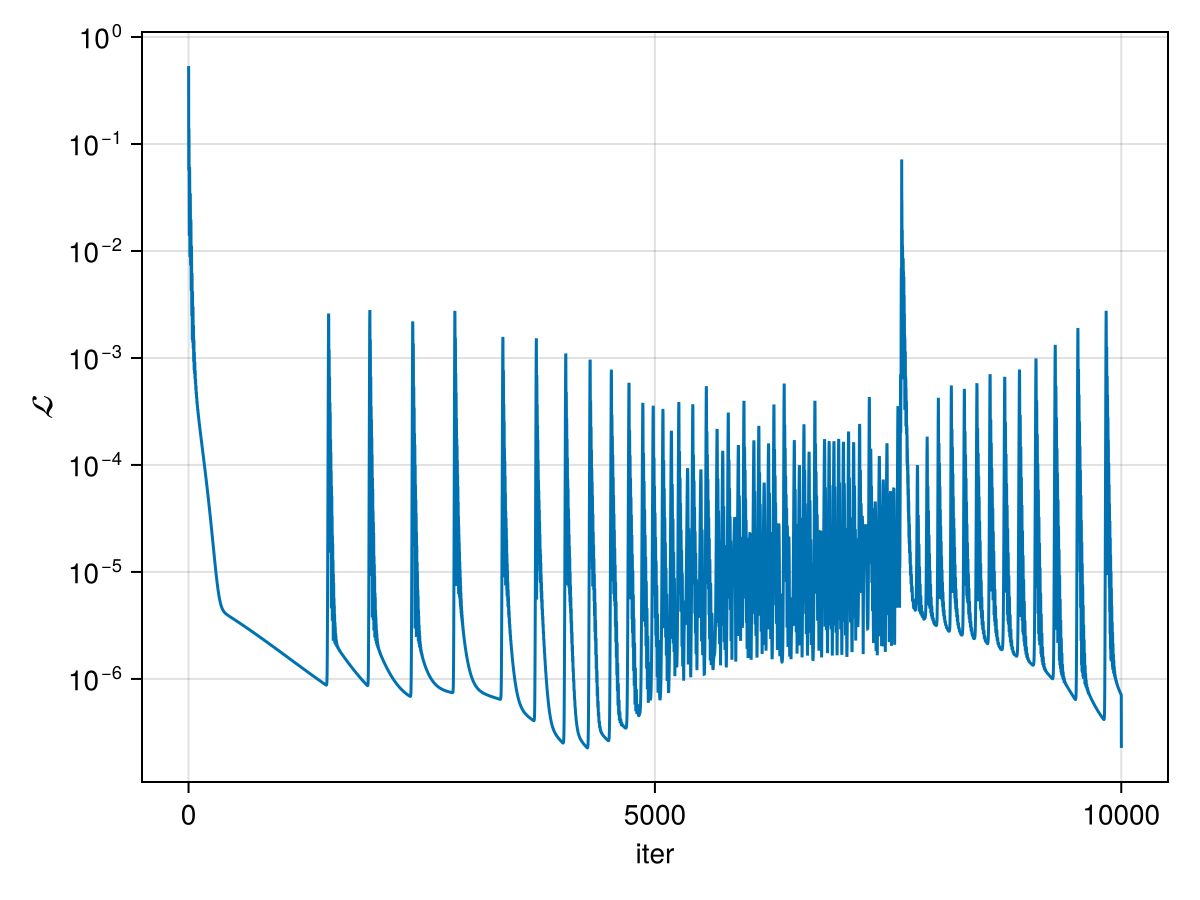

In [103]:
#Plot loss function
#
loss_history_collocation=copy(loss_history)
fig = CairoMakie.Figure()
ax = CairoMakie.Axis(fig[1, 1],yscale=log10,xlabel="iter",ylabel=L"\mathcal{L}")
CairoMakie.lines!(ax,loss_history_collocation)
#save("loss_collocation.png", fig)
fig


Look at Neural Network prediction of $du/dt=NN(u,p)$ and compare with the true $du/dt=-u^2$

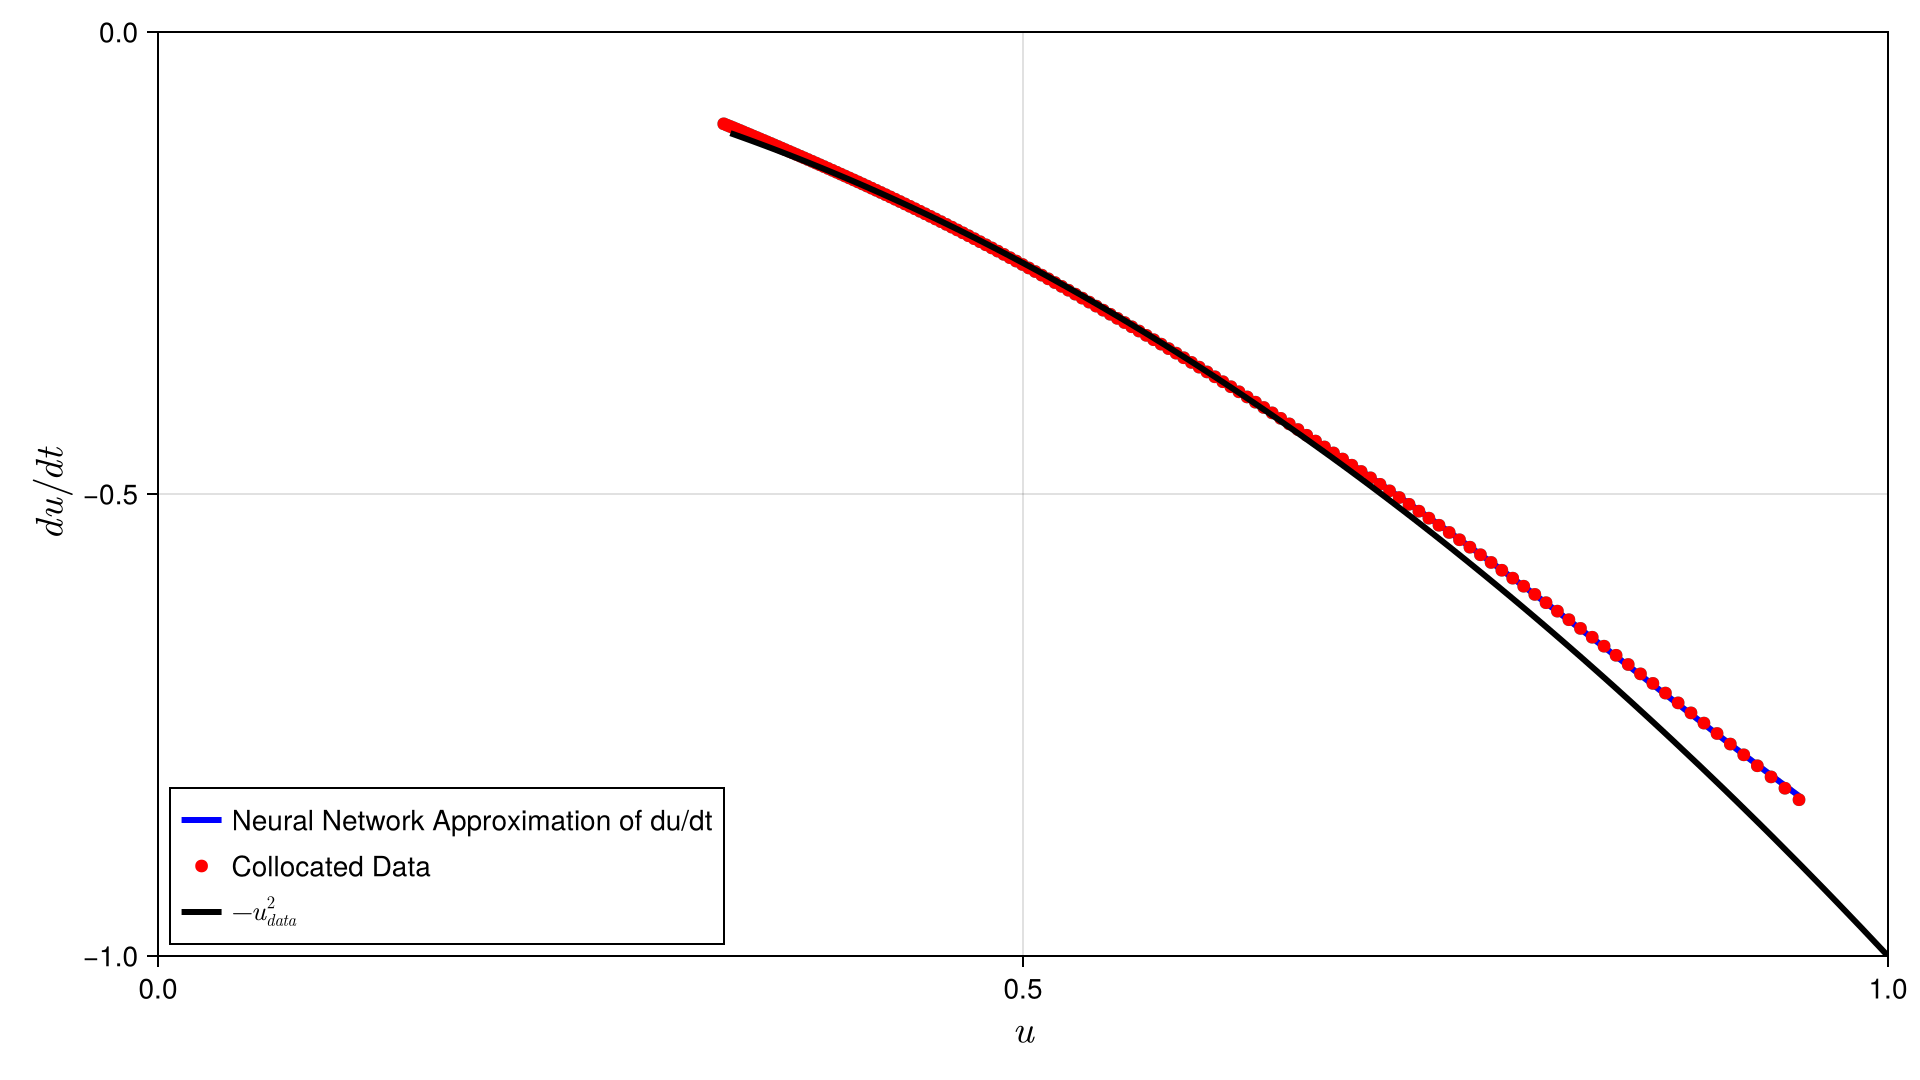

In [104]:
du_pred,_=dudtNODEs(u, result_neuralode.u, st)
fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"u",ylabel=L"du/dt")
CairoMakie.lines!(ax,u[1,:],du_pred[1,:],linewidth=3,color=:blue,label="Neural Network Approximation of du/dt")
CairoMakie.scatter!(ax,u[1,:],du[1,:],marker=:circle,color=:red,label="Collocated Data")
CairoMakie.lines!(ax,data[1,:],-data[1,:].*data[1,:],linewidth=3,color=:black,label=L"-u_{data}^2")
xlims!(ax,0,1)
ylims!(ax,-1,0)
axislegend(ax;position=:lb)
#save("figures/02_NeuralNetworkPrediction.png", fig)
fig

Predict using model for collocation training and compare with validation data

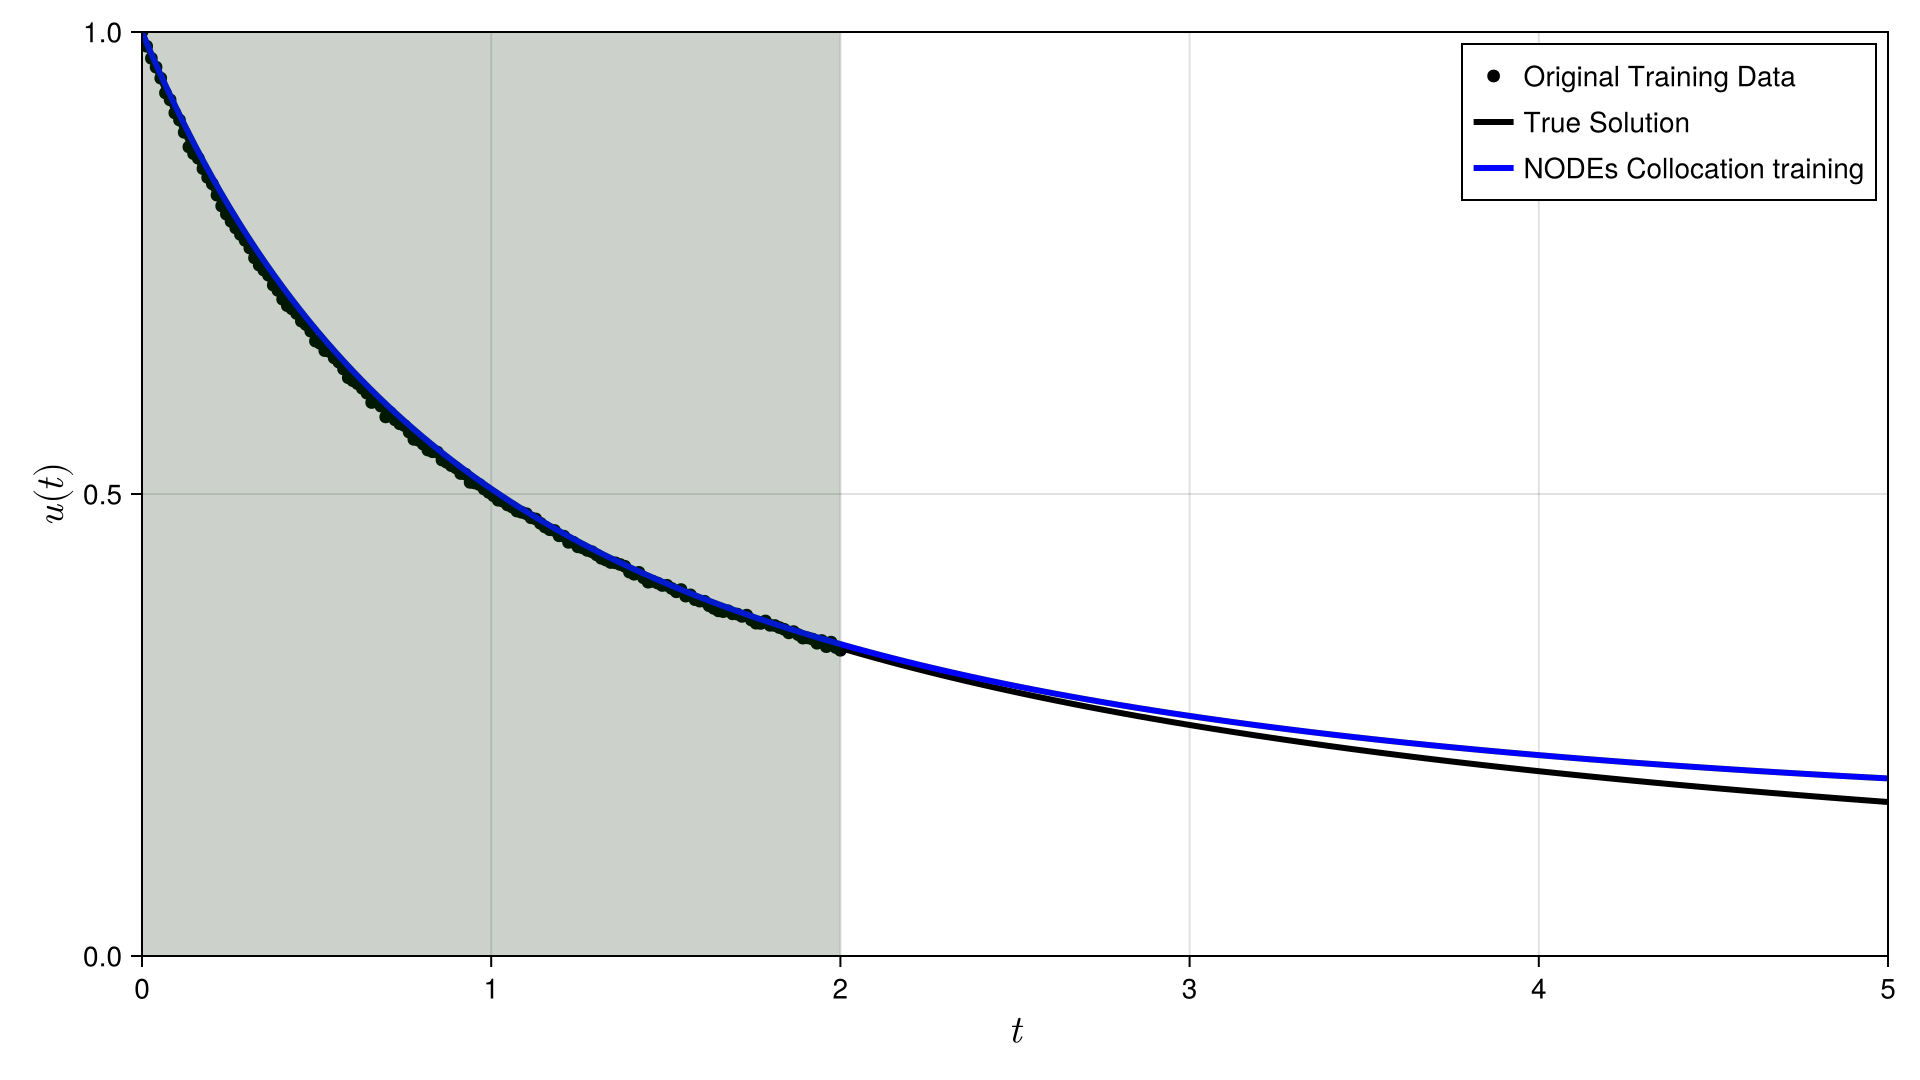

In [105]:
prob_colloc = ODEProblem(dudt_colloc, u0, (tspan2[1], tspan2[2]),result_neuralode.u)
nn_sol_colloc = solve(prob_colloc, Tsit5(); sensealg=InterpolatingAdjoint(), saveat=tsteps2)
ComputedSolutionColloc=convert(AbstractArray,nn_sol_colloc)

fig = CairoMakie.Figure(size = (960, 540), backgroundcolor = :transparent)
ax = CairoMakie.Axis(fig[1, 1],
    backgroundcolor = :transparent,
    xlabelsize=20,
    ylabelsize=20,
    xlabel=L"t",ylabel=L"u(t)")
CairoMakie.scatter!(ax,tsteps, data[1,:];color=:black,label="Original Training Data")
CairoMakie.lines!(ax,tsteps2, data_true[1,:]; linewidth = 3,color=:black,label="True Solution")
CairoMakie.lines!(ax,nn_sol_colloc.t,ComputedSolutionColloc[1,:]; linewidth = 3,color=:blue,linestyle=:solid,label="NODEs Collocation training")
CairoMakie.vspan!(ax,tspan[1], tspan[2];color=(:green, 0.2))
xlims!(ax,tspan2[1],tspan2[2])
ylims!(ax,0,1)
axislegend(ax;position=:rt)
#save("figures/02_NeuralODEsCollocationTraining.png", fig)
fig

---
**Workshop Demo 01:**   Rerun this example with EpanechnikovKernelBandwidth=0.2.  

---